![logo](./figures/LogoLine_horizon_C3S.png)

# Monthly mean of daily accumulated potential evapotranspiration

This Jupyter Notebook calculates the index **pet** (monthly mean of daily accumulated potential evapotranspiration) using the method described in [Hargreaves, G. H., and Samani, Z. A. (1985)](https://elibrary.asabe.org/abstract.asp??JID=3&AID=26773&CID=aeaj1985&v=1&i=2&T=1).

For a quick demonstration, the calculation is performed over a specific region (Spain), CMIP6 model (CMIP6-ACCESS_CM2 model) and experiment (ssp585).

First, the raw CMIP6 data is downloaded from the CDS, then the index is calculated, and the results are compared with the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview), also downloaded from the CDS.

### Load Python packages and clone and install the c3s-atlas GitHub repository from the ecmwf-projects

Clone (`git clone`) the [c3s-atlas](https://github.com/ecmwf-projects/c3s-atlas) repository and install it (`pip install -e .`).

Further details on installation are available in the [requirements section](https://github.com/ecmwf-projects/c3s-atlas?tab=readme-ov-file#requirements).

In [1]:
import os 
import glob
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import xarray as xr
import cdsapi

import xclim
from xclim.core.units import convert_units_to
from xclim.core.units import (
    amount2rate,
    rate2amount
)
import c3s_atlas.interpolation as xesmfCICA
from c3s_atlas.utils import (
    extract_zip_and_delete
)
from c3s_atlas.fixers import (
    apply_fixers
)


### Download climate data with the CDS API

To reduce data size and download time, a geographical subset focusing on Spain is selected.

- Catalogue: [CMIP6 climate projections](https://cds.climate.copernicus.eu/datasets/projections-cmip6?tab=overview)


> ⚠️ **Warning: Exposed API Credentials**
>
> For security reasons, it is not recommended to hardcode your Copernicus Climate Data Store (CDS) API credentials in notebooks.
>
> Instead, store them securely in a `.cdsapirc` file in your home directory.
>
> 📄 More info: [CDS API - How to use the API](https://cds.climate.copernicus.eu/how-to-api)

In [2]:
cdsapi_url = "https://cds.climate.copernicus.eu/api"
cdsapi_key = ""

In [3]:
c = cdsapi.Client(url=cdsapi_url, key=cdsapi_key)

Running the code blocks bellow will download the data from the CDS as specified by the following API keywords:

**Project:** `CMIP6 (Coupled Model Intercomparison Project Phase 6)`\
**Variables:** `Daily Maximum Near-Surface Air Temperature; Daily Minimum Near-Surface Air Temperature`  
**Temporal Resolution:** `Daily`  
**Model:** `ACCESS-CM2`  
**Experiment:** `SSP5-8.5`  
**Period:** `2015–2100`  
**Month:** `All`  
**Day:** `All`  
**Area:** `[45.5, 5.5, 34, −11.5]` (Cropped over Spain)

In [4]:
# define some global attributes for the CDS-API
dataset = "projections-cmip6"
# variables
CMIP6_variables = {
    'tasmax': 'daily_maximum_near_surface_air_temperature',
    'tasmin': 'daily_minimum_near_surface_air_temperature',
}
CMIP6_years = {
    "ssp5_8_5": [str(year) for year in range(2015, 2101)],
}
file_dest_CMIP6 = Path('./data/CMIP6')

In [5]:
months=[
    "01", "02", "03",
    "04", "05", "06",
    "07", "08", "09",
    "10", "11", "12"
]
day=[
    "01", "02", "03",
    "04", "05", "06",
    "07", "08", "09",
    "10", "11", "12",
    "13", "14", "15",
    "16", "17", "18",
    "19", "20", "21",
    "22", "23", "24",
    "25", "26", "27",
    "28", "29", "30",
    "31"
]

In [ ]:
os.makedirs(file_dest_CMIP6, exist_ok=True)

for experiment in CMIP6_years.keys():
    for var in CMIP6_variables.keys():
        path_zip = file_dest_CMIP6 / f"CMIP6_daily_{var}_{experiment}_{CMIP6_years[experiment][0]}-{CMIP6_years[experiment][-1]}_Spain.zip"
        request = {
            "temporal_resolution": "daily",
            "experiment": experiment,
            "variable": CMIP6_variables[var],
                "model": "access_cm2",
                "year": CMIP6_years[experiment],
                "month": months,
                "day": day,
                'area':[45.5, 5.5, 34, -11.5], # crop area for Spain                 
            }

        print(f"Launching request {request} and saving to {path_zip}")
        c.retrieve(dataset, request, path_zip)
        extract_zip_and_delete(path_zip)

### Load files with xarray

In [6]:
# load files
ds_tasmax = xr.open_dataset(file_dest_CMIP6 / "CMIP6_daily_tasmax_ssp5_8_5_2015-2100_Spain.nc")
ds_tasmin = xr.open_dataset(file_dest_CMIP6 / "CMIP6_daily_tasmin_ssp5_8_5_2015-2100_Spain.nc")

### Homogenization

Once the data is downloaded from the CDS it undergoes a process of homogenization (see the ["Homogenization"](https://github.com/ecmwf-projects/c3s-atlas/blob/main/c3s_atlas/README.md) section for more details). 

- `dataset_variable`: Renames the variable using, respectively, the original (raw) variable name and the corresponding C3S Atlas variable name provided as inputs.
- `aggregation`: Specifies the aggregation function applied to resample the data to either monthly or daily temporal resolution.

In [7]:
project_id = "cmip6"
var_mapping = {
            "dataset_variable": {"tasmax": "tasmax",
                                 "tasmin": "tasmin",},
            "aggregation": {"tasmax": "mean",
                            "tasmin": "mean"},
        }
ds_tasmax = apply_fixers(ds_tasmax, "tasmax", "CMIP6", var_mapping)
ds_tasmin = apply_fixers(ds_tasmin, "tasmin", "CMIP6", var_mapping)

2026-02-20 11:06:05,992 — Homogenization-fixers — INFO — Dataset has already the correct names for its coordinates
2026-02-20 11:06:06,015 — Homogenization-fixers — INFO — Fixing calendar for <xarray.Dataset> Size: 20MB
Dimensions:    (time: 31411, bnds: 2, lat: 9, lon: 9)
Coordinates:
  * time       (time) datetime64[ns] 251kB 2015-01-01T12:00:00 ... 2100-12-31...
  * lat        (lat) float64 72B 34.38 35.62 36.88 38.12 ... 41.88 43.12 44.38
  * lon        (lon) float64 72B -10.31 -8.438 -6.562 ... 0.9375 2.812 4.688
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 503kB ...
    lat_bnds   (time, lat, bnds) float64 5MB ...
    lon_bnds   (time, lon, bnds) float64 5MB ...
    tasmax     (time, lat, lon) float32 10MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_

In [8]:
ds_tasmin["tasmin"].attrs["units"] = "degC"
ds_tasmax["tasmax"].attrs["units"] = "degC"

### Calculation of PET index using the Hargreaves-Samani (1985) method

The PET index is computed using daily minimum/maximum temperatures and extraterrestrial solar radiation. The calculation follows the [Hargreaves, G. H., and Samani, Z. A. (1985)](https://elibrary.asabe.org/abstract.asp??JID=3&AID=26773&CID=aeaj1985&v=1&i=2&T=1) formula implemented in [xclim](https://xclim.readthedocs.io/en/stable/_modules/xclim/indices/converters.html#potential_evapotranspiration).

In [9]:
ds_pet = xclim.indices.potential_evapotranspiration(
    tasmin = ds_tasmin["tasmin"],tasmax=ds_tasmax["tasmax"],method="HG85"
)

###  PET  unit transformations 

The  xclim function outputs PET in "kg m-2 s-1", while the PET values in the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) are given in "mm" (mm/day). Therefore, the units are converted to "mm/day" for comparison.

In [10]:
ds_pet=convert_units_to(ds_pet, "mm/d", context="hydro")
ds_pet=rate2amount(ds_pet,out_units="mm")

###  Aggregate to monthly
Aggregate to monthly (MS) temporal resolution using xarray resample function

In [11]:
ds_pet = ds_pet.resample(time="MS").mean()
ds_pet=ds_pet.to_dataset(name="pet")

### Interpolation to a common and regular grid using xESMF

A wrapper for [xESMF](https://xesmf.readthedocs.io/en/stable/) is used to interpolate PET data onto a regular grid, ensuring comparability between model output and reference datasets. The coordinates are renamed in order to be compatible with the xESMF wrapper.

In [12]:
ds_pet = ds_pet.rename({'lat': 'latitude', 'lon': 'longitude'})
# interpolate data
int_attr = {'interpolation_method' : 'conservative_normed', 
            'lats' : np.arange(34.5, 46.5, 1),
            'lons' : np.arange(-11.5, 6.5, 1),
            'var_name' : 'pet'
}

INTER = xesmfCICA.Interpolator(int_attr)
ds_pet_i = INTER(ds_pet)

## Compare the results with the "Gridded dataset underpinning the Copernicus Interactive Climate Atlas"

- Catalogue: [Gridded dataset underpinning the Copernicus Interactive Climate Atlas](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview)

#### Download the data

Running the code blocks bellow will download the data from the CDS as specified by the following API keywords:

**Project:** `C3S Atlas dataset`\
**Origin:** `CMIP6`\
**Variables:** `Monthly Daily Accumulated Potential Evapotranspiration`  
**Origin:** `CMIP6`  
**Experiment:** `SSP5-8.5`  
**Period:** `2015–2100`  
**Area:** `[45.5, 5.5, 34, −11.5]` (Cropped over Spain)

In [ ]:
# Download CMIP6 PET data for Spain
variables_c3s= {
    "pet": "monthly_daily_accumulated_potential_evapotranspiration",
}
period_ssp="2015-2100"
dataset="cmip6"
experiment='ssp5_8_5'
catalogue_id = "multi-origin-c3s-atlas"
for var in variables_c3s.keys():
    path_zip = file_dest_CMIP6 / f"c3s-atlas-CMIP6_monthly_{var}_{experiment}_{period_ssp}_Spain.zip"
    request = {

        "origin": dataset,
        "experiment": experiment,
        "domain": "global",
        "period": period_ssp,
        "variable": variables_c3s[var],
        "area": [45.5, 5.5, 34, -11.5], # crop area for Spain
    }
    print(f"Launching request {request} and saving to {path_zip}")
    c.retrieve(catalogue_id, request, path_zip)
    extract_zip_and_delete(path_zip)

In [13]:
ds_pet_C3S_Atlas = xr.open_dataset(file_dest_CMIP6 / f"c3s-atlas-CMIP6_monthly_pet_ssp5_8_5_2015-2100_Spain.nc")

In [14]:
# select a specific member of the ensemble
select_member = [
    str(mem.data) for mem in ds_pet_C3S_Atlas.member_id if "access" in str(mem.data).lower()
][0]
print(select_member)

CSIRO-ARCCSS_ACCESS-CM2_r1i1p1f1


In [15]:
ds_pet_C3S_Atlas_member=ds_pet_C3S_Atlas.sel(member = np.where(ds_pet_C3S_Atlas.member_id.values == select_member)[0])

#### Plot results PET

Comparison between the results from this Jupyter notebook and the reference C3S Atlas dataset. A time series at a specific point in central Spain is used for the comparison. The figure shows that the results obtained with this notebook and from the C3S Atlas datasets are identical, and therefore fully reproducible.

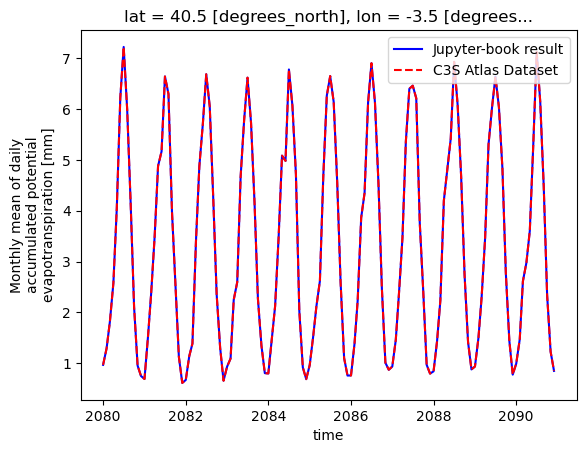

In [16]:
latitud = 40.0
longitud = -3.5
ds_pet_i_point_year=ds_pet_i.sel(lat=latitud, lon=longitud, method="nearest").sel(time=slice("2080-01-01","2090-12-31"))
ds_pet_C3S_Atlas_member_point_year=ds_pet_C3S_Atlas_member["pet"].sel(lat=latitud, lon=longitud, method="nearest").sel(time=slice("2080-01-01","2090-12-31"))
ds_pet_i_point_year["pet"].plot(linestyle = '-', color = 'b',label='Jupyter-book result')
ds_pet_C3S_Atlas_member_point_year.plot(linestyle = '--', color = 'r',label='C3S Atlas Dataset')
plt.legend()

#### Loading and applying the Barrean mask to the calculated PET index
A bare-earth (barren) mask has to be applied to the Standardized Precipitation Index (SPI), Standardized Precipitation Evapotranspiration Index (SPEI), and Potential Evapotranspiration (PET) to ensure meaningful results in arid or non-vegetated regions. More information and recipes for calculating the Barrean mask can be in found the [auxiliar](https://github.com/ecmwf-projects/c3s-atlas/blob/main/auxiliar/barrean_mask.ipynb) folder of the c3s-atlas repository.

In [17]:
barrean_ds=xr.open_dataset("../../auxiliar/reference-grids/barrean_mask_CMIP6.nc")
barrean_ds = barrean_ds.sel(
    lat=slice(ds_pet_i.lat.min(), ds_pet_i.lat.max()),
    lon=slice(ds_pet_i.lon.min(), ds_pet_i.lon.max())
)
ds_pet_i["pet"] = xr.where(
                        barrean_ds["barrean"] == 1, ds_pet_i["pet"], np.nan
                    )


### Plot results for the ssp585 period (2015-2100)

Comparison of the results obtained with present Jupyter notebook and the reference C3S Atlas Dataset underpinning the C3S Atlas. A geographical subset focusing on Spain is selected to show the results.


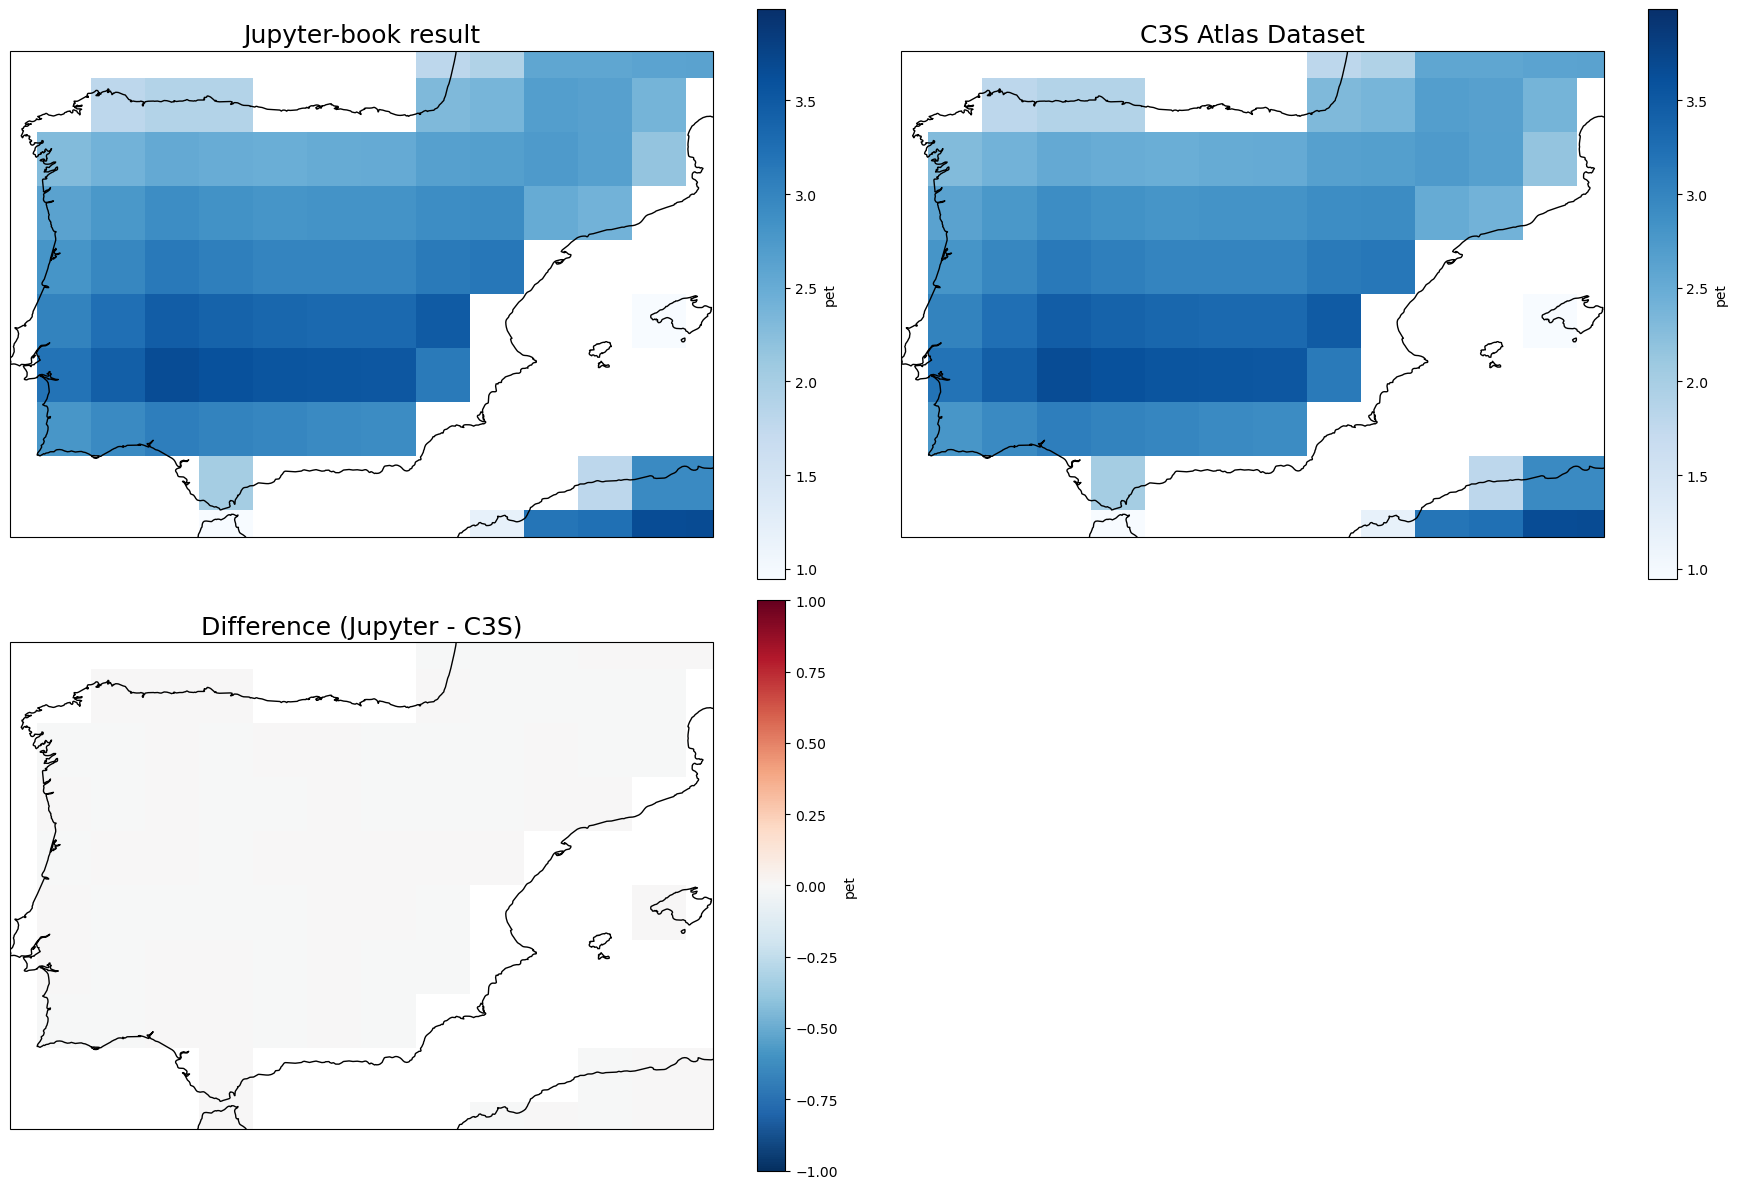

In [21]:
zoomin_extent = [-9.5, 3.5, 35.5, 44.5]
title_size = 18

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(
    nrows=2, ncols=2,
    subplot_kw={'projection': proj},
    figsize=(18, 12)
)

# calculate climatologies and the difference
pet_i_mean = ds_pet_i["pet"].mean(dim="time")
pet_c3s_mean = ds_pet_C3S_Atlas_member["pet"].mean(dim="time")
diff = pet_i_mean - pet_c3s_mean

pet_i_mean.plot(ax=ax[0, 0], cmap="Blues")
ax[0, 0].set_title("Jupyter-book result", fontsize = title_size)
ax[0, 0].set_extent(zoomin_extent)
ax[0, 0].coastlines()

pet_c3s_mean.plot(ax=ax[0, 1], cmap="Blues")
ax[0, 1].set_title("C3S Atlas Dataset", fontsize = title_size)
ax[0, 1].set_extent(zoomin_extent)
ax[0, 1].coastlines()

diff.plot(ax=ax[1, 0], cmap="RdBu_r", vmin=-1, vmax=1)
ax[1, 0].set_title("Difference (Jupyter - C3S)", fontsize = title_size)
ax[1, 0].set_extent(zoomin_extent)
ax[1, 0].coastlines()

# Eliminar el panel vacío
fig.delaxes(ax[1, 1])

plt.tight_layout()
plt.show()

The figure demonstrates that the results obtained with this notebook are identical to those from the C3S Atlas datasets, and are therefore fully reproducible.